# PI Few-Shot Raw CSI Prototypical Training

Train a SimID-inspired raw CSI prototypical encoder on the source PI domains, then compare target-domain K-shot prototype inference against the strongest saved Doppler feature-map prototypical model and the saved Doppler softmax classifier.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

RAW_CSI_DIR = PROJECT_ROOT / "data" / "raw_csi_traces_pi"
DOPPLER_DIR = PROJECT_ROOT / "data" / "doppler_traces_pi"

SOFTMAX_CHECKPOINT_PATH = PROJECT_ROOT / "experiments" / "pi_classification" / "pi_all_persons_123_train_4_test_sharp_model_20260525_165437" / "model.pt"
DOPPLER_FEATUREMAP_PROTO_CHECKPOINT_PATH = PROJECT_ROOT / "experiments" / "few_shot_proto_evaluation" / "proto_multi_antenna_vs_softmax_baseline_20260527_164722" / "proto_model.pt"

RUN_GROUP = "few_shot_raw_csi_proto_evaluation"
RUN_NAME = "raw_csi_proto_vs_doppler_featuremap_proto"


## Imports And Experiment Constants

In [2]:
import gc
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import clear_output, display
from torch.cuda import is_available
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from wifi_doppler.data.doppler_dataset import DopplerWindowDataset
from wifi_doppler.data.raw_csi_dataset import RawCsiWindowDataset
from wifi_doppler.evaluation.fewshot import evaluate_kshot, window_true_labels_from_recordings
from wifi_doppler.experiments.artifacts import create_run_dir, plot_step_curves, save_checkpoint, save_figure, save_json
from wifi_doppler.models.raw_csi import RawCsiTemporalEncoder, count_trainable_parameters
from wifi_doppler.models.sharp import MultiAntennaModel, SingleAntennaModel
from wifi_doppler.training.prototypical import load_cross_dataset_episode, load_episode, prototypical_loss, sample_cross_dataset_episode_indices, sample_episode_indices

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if is_available() else "cpu"
softmax_checkpoint = torch.load(SOFTMAX_CHECKPOINT_PATH, map_location=device, weights_only=False)
softmax_config = softmax_checkpoint["config"]

PERSONS = softmax_checkpoint["labels"]
TRAIN_SCENARIOS = softmax_config.get("train_scenarios", ["PI-1a", "PI-2a", "PI-3a"])
TARGET_SCENARIOS = softmax_config.get("test_scenarios", ["PI-4a"])
WINDOW_SIZE = softmax_config.get("window_size", 340)
WINDOW_STRIDE = softmax_config.get("window_stride", 30)
SPLIT_GUARD = softmax_config.get("split_guard", 31)
SOFTMAX_FUSION = softmax_config.get("fusion", "mean")

SOURCE_TRAIN_SPLIT = (0.0, 0.6)
SOURCE_VAL_SPLIT = (0.6, 0.8)
TARGET_ENROLLMENT_SPLIT = (0.0, 0.6)
TARGET_QUERY_SPLIT = (0.6, 0.8)

TOTAL_PROTO_STEPS = 3000
EVAL_EVERY_STEPS = 100
PROTO_TEST_EPISODES_PER_EVAL = 2
LIVE_PLOT_EVERY_STEPS = 1
PROTO_N_WAY = len(PERSONS)
PROTO_K_SHOT = 5
PROTO_Q_QUERY = 8
PROTO_LR = 1e-4
PROTO_EMBEDDING_DIM = 128
RAW_IN_CHANNELS = 4 * 242
RAW_CHANNEL_MIXER_DIM = 128
RAW_HIDDEN_DIM = 256
PROTO_TEMPERATURE = 0.1
EARLY_STOP_METRIC = "proto_source_val_acc"
EARLY_STOP_PATIENCE_EVALS = 5
EARLY_STOP_MIN_DELTA = 0.0
EMBEDDING_FUSION = "mean"  # Ignored by the raw CSI wrapper; used by Doppler baselines.
METRIC = "cosine"

K_VALUES = [1, 3, 5, 10, 25, 50, 100]
N_TRIALS = 20
EVAL_BATCH_SIZE = 128

print("Raw CSI directory:", RAW_CSI_DIR)
print("Softmax checkpoint:", SOFTMAX_CHECKPOINT_PATH)
print("Doppler feature-map proto checkpoint:", DOPPLER_FEATUREMAP_PROTO_CHECKPOINT_PATH)
print("Train scenarios:", TRAIN_SCENARIOS)
print("Target scenarios:", TARGET_SCENARIOS)
print("Labels:", PERSONS)
print("Device:", device)


Raw CSI directory: C:\Users\gianm\Development\wifi-doppler-har\data\raw_csi_traces_pi
Softmax checkpoint: C:\Users\gianm\Development\wifi-doppler-har\experiments\pi_classification\pi_all_persons_123_train_4_test_sharp_model_20260525_165437\model.pt
Doppler feature-map proto checkpoint: C:\Users\gianm\Development\wifi-doppler-har\experiments\few_shot_proto_evaluation\proto_multi_antenna_vs_softmax_baseline_20260527_164722\proto_model.pt
Train scenarios: ['PI-1a', 'PI-2a', 'PI-3a']
Target scenarios: ['PI-4a']
Labels: ['p03', 'p05', 'p06', 'p07', 'p08', 'p09', 'p10', 'p11', 'p12', 'p13']
Device: cuda


## Build Raw CSI And Doppler Datasets

The raw CSI encoder is trained and evaluated on saved raw CSI amplitude traces. The Doppler datasets are only used to evaluate the saved Doppler baselines on the matching target-domain split.

In [3]:
raw_train_dataset = RawCsiWindowDataset(
    RAW_CSI_DIR,
    scenarios=TRAIN_SCENARIOS,
    split=SOURCE_TRAIN_SPLIT,
    window_size=WINDOW_SIZE,
    window_stride=WINDOW_STRIDE,
    split_guard=SPLIT_GUARD,
    labels=PERSONS,
    flatten_channels=True,
    cache_traces=True,
)

raw_source_val_dataset = RawCsiWindowDataset(
    RAW_CSI_DIR,
    scenarios=TRAIN_SCENARIOS,
    split=SOURCE_VAL_SPLIT,
    window_size=WINDOW_SIZE,
    window_stride=WINDOW_STRIDE,
    split_guard=SPLIT_GUARD,
    labels=PERSONS,
    flatten_channels=True,
    cache_traces=True,
)

raw_target_enrollment_dataset = RawCsiWindowDataset(
    RAW_CSI_DIR,
    scenarios=TARGET_SCENARIOS,
    split=TARGET_ENROLLMENT_SPLIT,
    window_size=WINDOW_SIZE,
    window_stride=WINDOW_STRIDE,
    split_guard=SPLIT_GUARD,
    labels=PERSONS,
    flatten_channels=True,
    cache_traces=True,
)

raw_target_query_dataset = RawCsiWindowDataset(
    RAW_CSI_DIR,
    scenarios=TARGET_SCENARIOS,
    split=TARGET_QUERY_SPLIT,
    window_size=WINDOW_SIZE,
    window_stride=WINDOW_STRIDE,
    split_guard=SPLIT_GUARD,
    labels=PERSONS,
    flatten_channels=True,
    cache_traces=True,
)

doppler_target_enrollment_dataset = DopplerWindowDataset(
    DOPPLER_DIR,
    scenarios=TARGET_SCENARIOS,
    split=TARGET_ENROLLMENT_SPLIT,
    window_size=WINDOW_SIZE,
    window_stride=WINDOW_STRIDE,
    split_guard=SPLIT_GUARD,
    labels=PERSONS,
)

doppler_target_query_dataset = DopplerWindowDataset(
    DOPPLER_DIR,
    scenarios=TARGET_SCENARIOS,
    split=TARGET_QUERY_SPLIT,
    window_size=WINDOW_SIZE,
    window_stride=WINDOW_STRIDE,
    split_guard=SPLIT_GUARD,
    labels=PERSONS,
)

raw_train_labels = window_true_labels_from_recordings(raw_train_dataset)
raw_source_val_labels = window_true_labels_from_recordings(raw_source_val_dataset)
raw_target_enrollment_labels = window_true_labels_from_recordings(raw_target_enrollment_dataset)
raw_target_query_labels = window_true_labels_from_recordings(raw_target_query_dataset)

print("Raw source train windows:", len(raw_train_dataset))
print("Raw source validation windows:", len(raw_source_val_dataset))
print("Raw target enrollment windows:", len(raw_target_enrollment_dataset))
print("Raw target query windows:", len(raw_target_query_dataset))
print("Doppler target enrollment windows:", len(doppler_target_enrollment_dataset))
print("Doppler target query windows:", len(doppler_target_query_dataset))
print("Raw sample shape:", tuple(raw_train_dataset[0][0].shape))
print("Doppler sample shape:", tuple(doppler_target_query_dataset[0][0].shape))


Raw source train windows: 27780
Raw source validation windows: 9011
Raw target enrollment windows: 9061
Raw target query windows: 2940
Doppler target enrollment windows: 8738
Doppler target query windows: 2830
Raw sample shape: (968, 340)
Doppler sample shape: (4, 340, 100)


## Train Raw CSI Prototypical Encoder

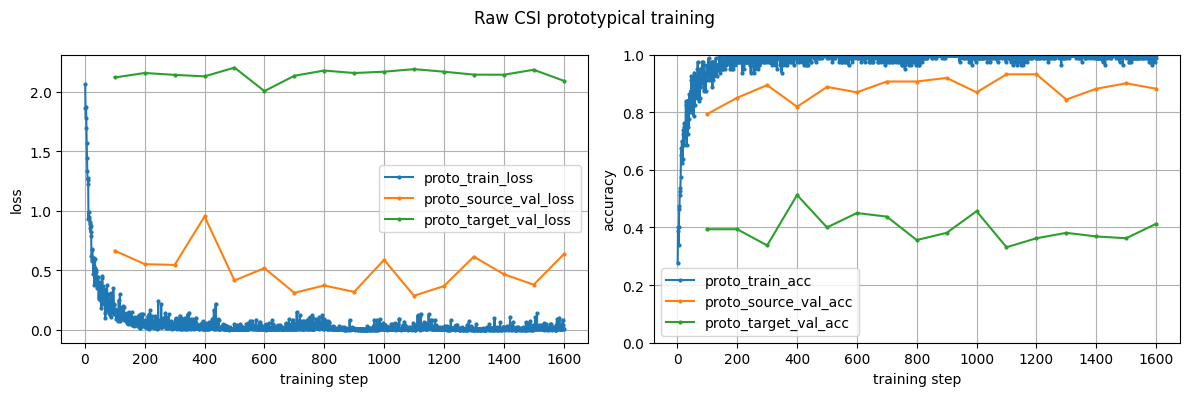

step 1600/3000: proto_train_loss=0.0039 proto_train_acc=1.0000 proto_source_val_loss=0.6325 proto_source_val_acc=0.8813 proto_target_val_loss=2.0932 proto_target_val_acc=0.4125
No proto_source_val_acc improvement for 5/5 evals
Early stopping at step 1600. Best proto_source_val_acc=0.9313 at step 1100.
Saved trained raw CSI proto model before few-shot evaluation: C:\Users\gianm\Development\wifi-doppler-har\experiments\few_shot_raw_csi_proto_evaluation\raw_csi_proto_vs_doppler_featuremap_proto_20260529_173630\proto_model_after_training.pt
Loaded best raw CSI proto model from step 1100 for few-shot evaluation.
Cleared cached raw CSI arrays before few-shot evaluation.


In [4]:
class RawCsiProtoModel(torch.nn.Module):
    """Adapter that makes RawCsiTemporalEncoder compatible with existing proto helpers."""

    def __init__(self):
        super().__init__()
        self.encoder = RawCsiTemporalEncoder(
            in_channels=RAW_IN_CHANNELS,
            embedding_dim=PROTO_EMBEDDING_DIM,
            channel_mixer_dim=RAW_CHANNEL_MIXER_DIM,
            hidden_dim=RAW_HIDDEN_DIM,
            normalize=True,
        )

    def forward_embedding(self, x, fusion=None):
        return self.encoder.forward_embedding(x)

    def forward(self, x):
        return self.forward_embedding(x)


def build_raw_proto_encoder(device: str | torch.device):
    model = RawCsiProtoModel().to(device)
    with torch.no_grad():
        dummy = raw_target_enrollment_dataset[0][0].unsqueeze(0).to(device)
        _ = model.forward_embedding(dummy)
    print("Raw CSI proto trainable parameters:", count_trainable_parameters(model))
    return model


def build_legacy_doppler_model(num_classes: int, device: str | torch.device):
    model = MultiAntennaModel(SingleAntennaModel(num_classes=num_classes)).to(device)
    with torch.no_grad():
        dummy = doppler_target_enrollment_dataset[0][0].unsqueeze(0).to(device)
        _ = model.forward_antennas(dummy)
    return model


def load_raw_episode_fast(dataset, support_indices, query_indices):
    """Load raw CSI episode windows while reading each trace file once."""
    all_indices = list(support_indices) + list(query_indices)
    by_recording = {}
    for pos, dataset_idx in enumerate(all_indices):
        window = dataset.window_indexes[int(dataset_idx)]
        by_recording.setdefault(window.recording_idx, []).append((pos, window))

    samples = [None] * len(all_indices)
    labels = [None] * len(all_indices)
    for recording_idx, items in by_recording.items():
        recording = dataset.traces[recording_idx]
        csi = recording.load()
        label = torch.tensor(dataset._label_to_index(recording.ground_truth), dtype=torch.long)
        for pos, window in items:
            samples[pos] = dataset.slice_csi_window(csi, window.start, window.end)
            labels[pos] = label

    n_support = len(support_indices)
    support_samples = samples[:n_support]
    support_labels = labels[:n_support]
    query_samples = samples[n_support:]
    query_labels = labels[n_support:]

    support_x = torch.stack(support_samples) if support_samples else None
    support_y = torch.stack(support_labels) if support_labels else None
    query_x = torch.stack(query_samples) if query_samples else None
    query_y = torch.stack(query_labels) if query_labels else None
    return support_x, support_y, query_x, query_y


def raw_prototypical_loss(model, support_x, support_y, query_x, query_y):
    support_x = support_x.to(device)
    support_y = support_y.to(device)
    query_x = query_x.to(device)
    query_y = query_y.to(device)

    support_embeddings = model.forward_embedding(support_x)
    query_embeddings = model.forward_embedding(query_x)

    from wifi_doppler.representation.prototypes import compute_prototypes, map_labels_to_prototype_indices, prototype_logits
    prototypes, prototype_labels = compute_prototypes(support_embeddings, support_y, normalize=True)
    logits = prototype_logits(query_embeddings, prototypes, metric=METRIC) / PROTO_TEMPERATURE
    targets = map_labels_to_prototype_indices(query_y, prototype_labels)
    loss = torch.nn.functional.cross_entropy(logits, targets)
    acc = (logits.argmax(dim=1) == targets).float().mean().item()
    return loss, acc


def evaluate_same_dataset_proto_episodes(model, dataset, labels, rng):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    with torch.no_grad():
        for _ in range(PROTO_TEST_EPISODES_PER_EVAL):
            support_indices, query_indices = sample_episode_indices(labels, n_way=PROTO_N_WAY, k_shot=PROTO_K_SHOT, q_query=PROTO_Q_QUERY, rng=rng)
            support_x, support_y, query_x, query_y = load_raw_episode_fast(dataset, support_indices, query_indices)
            loss, acc = raw_prototypical_loss(model, support_x, support_y, query_x, query_y)
            total_loss += loss.item()
            total_acc += acc

    return {"loss": total_loss / PROTO_TEST_EPISODES_PER_EVAL, "acc": total_acc / PROTO_TEST_EPISODES_PER_EVAL}


def evaluate_cross_dataset_proto_episodes(model, support_dataset, support_labels, query_dataset, query_labels, rng):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    with torch.no_grad():
        for _ in range(PROTO_TEST_EPISODES_PER_EVAL):
            support_indices, query_indices = sample_cross_dataset_episode_indices(support_labels, query_labels, n_way=PROTO_N_WAY, k_shot=PROTO_K_SHOT, q_query=PROTO_Q_QUERY, rng=rng)
            support_x, support_y, _, _ = load_raw_episode_fast(support_dataset, support_indices, [])
            _, _, query_x, query_y = load_raw_episode_fast(query_dataset, [], query_indices)
            loss, acc = raw_prototypical_loss(model, support_x, support_y, query_x, query_y)
            total_loss += loss.item()
            total_acc += acc

    return {"loss": total_loss / PROTO_TEST_EPISODES_PER_EVAL, "acc": total_acc / PROTO_TEST_EPISODES_PER_EVAL}


def show_live_proto_curves(history):
    fig, _ = plot_step_curves(
        history,
        loss_keys=["proto_train_loss", "proto_source_val_loss", "proto_target_val_loss"],
        acc_keys=["proto_train_acc", "proto_source_val_acc", "proto_target_val_acc"],
        title="Raw CSI prototypical training",
    )
    clear_output(wait=True)
    display(fig)
    plt.close(fig)


proto_config = {
    "raw_csi_dir": RAW_CSI_DIR,
    "doppler_dir": DOPPLER_DIR,
    "baseline_softmax_checkpoint": SOFTMAX_CHECKPOINT_PATH,
    "baseline_doppler_featuremap_proto_checkpoint": DOPPLER_FEATUREMAP_PROTO_CHECKPOINT_PATH,
    "train_scenarios": TRAIN_SCENARIOS,
    "target_scenarios": TARGET_SCENARIOS,
    "source_train_split": SOURCE_TRAIN_SPLIT,
    "source_val_split": SOURCE_VAL_SPLIT,
    "target_enrollment_split": TARGET_ENROLLMENT_SPLIT,
    "target_query_split": TARGET_QUERY_SPLIT,
    "window_size": WINDOW_SIZE,
    "window_stride": WINDOW_STRIDE,
    "split_guard": SPLIT_GUARD,
    "raw_in_channels": RAW_IN_CHANNELS,
    "raw_channel_mixer_dim": RAW_CHANNEL_MIXER_DIM,
    "raw_hidden_dim": RAW_HIDDEN_DIM,
    "proto_embedding_dim": PROTO_EMBEDDING_DIM,
    "total_proto_steps": TOTAL_PROTO_STEPS,
    "eval_every_steps": EVAL_EVERY_STEPS,
    "proto_val_episodes_per_eval": PROTO_TEST_EPISODES_PER_EVAL,
    "live_plot_every_steps": LIVE_PLOT_EVERY_STEPS,
    "proto_n_way": PROTO_N_WAY,
    "proto_k_shot": PROTO_K_SHOT,
    "proto_q_query": PROTO_Q_QUERY,
    "proto_lr": PROTO_LR,
    "proto_temperature": PROTO_TEMPERATURE,
    "early_stop_metric": EARLY_STOP_METRIC,
    "early_stop_patience_evals": EARLY_STOP_PATIENCE_EVALS,
    "early_stop_min_delta": EARLY_STOP_MIN_DELTA,
    "metric": METRIC,
    "k_values": K_VALUES,
    "n_trials": N_TRIALS,
    "seed": SEED,
}

run_dir = create_run_dir(PROJECT_ROOT, RUN_GROUP, RUN_NAME)
save_json(run_dir / "proto_config.json", proto_config)
print("Run directory:", run_dir)


def latest_proto_metrics(history):
    return {
        "step": history["step"][-1],
        "latest_proto_train_loss": history["proto_train_loss"][-1],
        "latest_proto_train_acc": history["proto_train_acc"][-1],
        "latest_proto_source_val_loss": history["proto_source_val_loss"][-1],
        "latest_proto_source_val_acc": history["proto_source_val_acc"][-1],
        "latest_proto_target_val_loss": history["proto_target_val_loss"][-1],
        "latest_proto_target_val_acc": history["proto_target_val_acc"][-1],
    }


def is_better_metric(value, best_value):
    return np.isfinite(value) and value > best_value + EARLY_STOP_MIN_DELTA


proto_model = build_raw_proto_encoder(device)
optimizer = torch.optim.Adam(proto_model.parameters(), lr=PROTO_LR)
episode_rng = np.random.default_rng(SEED)
source_val_episode_rng = np.random.default_rng(SEED + 1)
target_val_episode_rng = np.random.default_rng(SEED + 2)

proto_history = {
    "step": [],
    "proto_train_loss": [],
    "proto_train_acc": [],
    "proto_source_val_loss": [],
    "proto_source_val_acc": [],
    "proto_target_val_loss": [],
    "proto_target_val_acc": [],
}
best_metric_value = -np.inf
best_metric_step = None
best_checkpoint_path = run_dir / "proto_model_best.pt"
evals_without_improvement = 0
stopped_early = False

progress = tqdm(range(1, TOTAL_PROTO_STEPS + 1), desc="raw CSI proto training steps")
for step in progress:
    proto_model.train()
    support_indices, query_indices = sample_episode_indices(raw_train_labels, n_way=PROTO_N_WAY, k_shot=PROTO_K_SHOT, q_query=PROTO_Q_QUERY, rng=episode_rng)
    support_x, support_y, query_x, query_y = load_raw_episode_fast(raw_train_dataset, support_indices, query_indices)

    optimizer.zero_grad()
    loss, acc = raw_prototypical_loss(proto_model, support_x, support_y, query_x, query_y)
    loss.backward()
    optimizer.step()

    source_val_metrics = {"loss": np.nan, "acc": np.nan}
    target_val_metrics = {"loss": np.nan, "acc": np.nan}
    should_eval = step % EVAL_EVERY_STEPS == 0 or step == TOTAL_PROTO_STEPS
    if should_eval:
        source_val_metrics = evaluate_same_dataset_proto_episodes(proto_model, raw_source_val_dataset, raw_source_val_labels, source_val_episode_rng)
        target_val_metrics = evaluate_cross_dataset_proto_episodes(proto_model, raw_target_enrollment_dataset, raw_target_enrollment_labels, raw_target_query_dataset, raw_target_query_labels, target_val_episode_rng)

    proto_history["step"].append(step)
    proto_history["proto_train_loss"].append(loss.item())
    proto_history["proto_train_acc"].append(acc)
    proto_history["proto_source_val_loss"].append(source_val_metrics["loss"])
    proto_history["proto_source_val_acc"].append(source_val_metrics["acc"])
    proto_history["proto_target_val_loss"].append(target_val_metrics["loss"])
    proto_history["proto_target_val_acc"].append(target_val_metrics["acc"])

    progress.set_postfix(train_loss=f"{loss.item():.4f}", train_acc=f"{acc:.4f}", source_acc="nan" if np.isnan(source_val_metrics["acc"]) else f"{source_val_metrics['acc']:.4f}", target_acc="nan" if np.isnan(target_val_metrics["acc"]) else f"{target_val_metrics['acc']:.4f}")

    if step == 1 or step % LIVE_PLOT_EVERY_STEPS == 0 or step == TOTAL_PROTO_STEPS:
        show_live_proto_curves(proto_history)
        print(f"step {step:04d}/{TOTAL_PROTO_STEPS}: proto_train_loss={loss.item():.4f} proto_train_acc={acc:.4f} proto_source_val_loss={source_val_metrics['loss']:.4f} proto_source_val_acc={source_val_metrics['acc']:.4f} proto_target_val_loss={target_val_metrics['loss']:.4f} proto_target_val_acc={target_val_metrics['acc']:.4f}")

    if should_eval:
        save_checkpoint(proto_model, run_dir, labels=PERSONS, config=proto_config, metrics=latest_proto_metrics(proto_history), history=proto_history, name="proto_model_latest.pt")

        current_metric_value = proto_history[EARLY_STOP_METRIC][-1]
        if is_better_metric(current_metric_value, best_metric_value):
            best_metric_value = current_metric_value
            best_metric_step = step
            evals_without_improvement = 0
            save_checkpoint(proto_model, run_dir, labels=PERSONS, config=proto_config, metrics={**latest_proto_metrics(proto_history), "best_metric": EARLY_STOP_METRIC, "best_metric_value": best_metric_value, "best_metric_step": best_metric_step}, history=proto_history, name="proto_model_best.pt")
            print(f"New best {EARLY_STOP_METRIC}: {best_metric_value:.4f} at step {best_metric_step}")
        else:
            evals_without_improvement += 1
            print(f"No {EARLY_STOP_METRIC} improvement for {evals_without_improvement}/{EARLY_STOP_PATIENCE_EVALS} evals")

        if evals_without_improvement >= EARLY_STOP_PATIENCE_EVALS:
            stopped_early = True
            print(f"Early stopping at step {step}. Best {EARLY_STOP_METRIC}={best_metric_value:.4f} at step {best_metric_step}.")
            break

training_checkpoint_path = save_checkpoint(proto_model, run_dir, labels=PERSONS, config=proto_config, metrics={**latest_proto_metrics(proto_history), "best_metric": EARLY_STOP_METRIC, "best_metric_value": best_metric_value, "best_metric_step": best_metric_step, "stopped_early": stopped_early}, history=proto_history, name="proto_model_after_training.pt")
save_json(run_dir / "proto_training_history.json", {"history": proto_history, "config": proto_config, "selection": {"best_metric": EARLY_STOP_METRIC, "best_metric_value": best_metric_value, "best_metric_step": best_metric_step, "stopped_early": stopped_early}})
print("Saved trained raw CSI proto model before few-shot evaluation:", training_checkpoint_path)

best_checkpoint = torch.load(best_checkpoint_path, map_location=device, weights_only=False)
proto_model.load_state_dict(best_checkpoint["model_state_dict"])
proto_model.eval()
print(f"Loaded best raw CSI proto model from step {best_metric_step} for few-shot evaluation.")

for dataset in (raw_train_dataset, raw_source_val_dataset, raw_target_enrollment_dataset, raw_target_query_dataset):
    dataset.clear_cache()
gc.collect()
if is_available():
    torch.cuda.empty_cache()
print("Cleared cached raw CSI arrays before few-shot evaluation.")


## Load Doppler Baselines

In [5]:
softmax_model = build_legacy_doppler_model(len(PERSONS), device)
softmax_model.load_state_dict(softmax_checkpoint["model_state_dict"])
softmax_model.eval()

doppler_featuremap_proto_checkpoint = torch.load(
    DOPPLER_FEATUREMAP_PROTO_CHECKPOINT_PATH,
    map_location=device,
    weights_only=False,
)
doppler_featuremap_proto_model = build_legacy_doppler_model(len(PERSONS), device)
doppler_featuremap_proto_model.load_state_dict(doppler_featuremap_proto_checkpoint["model_state_dict"])
doppler_featuremap_proto_model.eval()

print("Loaded Doppler softmax baseline.")
print("Loaded Doppler feature-map prototypical baseline.")


Loaded Doppler softmax baseline.
Loaded Doppler feature-map prototypical baseline.


c:\Users\gianm\anaconda3\envs\wifi-doppler-har\Lib\site-packages\torch\nn\modules\conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1091.)
  return F.conv2d(


## Zero-Shot Doppler Softmax Accuracy

In [6]:
def evaluate_softmax_accuracy(model, dataset, device, fusion, batch_size=128):
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x, fusion=fusion)
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += y.size(0)
    return correct / total


zero_shot_softmax_acc = evaluate_softmax_accuracy(softmax_model, doppler_target_query_dataset, device, SOFTMAX_FUSION, batch_size=EVAL_BATCH_SIZE)
print(f"Zero-shot Doppler softmax accuracy on target query split: {zero_shot_softmax_acc:.4f}")


Zero-shot Doppler softmax accuracy on target query split: 0.3159


## K-Shot Prototype Inference Comparison

Compare the newly trained raw CSI prototypical encoder against the strongest saved Doppler feature-map prototypical model and the saved Doppler softmax model. Each model uses its own representation but the same PI target-domain split and K-shot protocol.

In [7]:
raw_proto_fewshot_results = evaluate_kshot(proto_model, raw_target_enrollment_dataset, raw_target_query_dataset, K_VALUES, device=device, n_trials=N_TRIALS, seed=SEED, batch_size=EVAL_BATCH_SIZE, embedding_fusion=EMBEDDING_FUSION, metric=METRIC)

doppler_featuremap_proto_fewshot_results = evaluate_kshot(doppler_featuremap_proto_model, doppler_target_enrollment_dataset, doppler_target_query_dataset, K_VALUES, device=device, n_trials=N_TRIALS, seed=SEED, batch_size=EVAL_BATCH_SIZE, embedding_fusion=EMBEDDING_FUSION, metric=METRIC)

doppler_softmax_fewshot_results = evaluate_kshot(softmax_model, doppler_target_enrollment_dataset, doppler_target_query_dataset, K_VALUES, device=device, n_trials=N_TRIALS, seed=SEED, batch_size=EVAL_BATCH_SIZE, embedding_fusion=EMBEDDING_FUSION, metric=METRIC)

print("K-shot target-domain query accuracy")
for k in K_VALUES:
    raw_result = raw_proto_fewshot_results[k]
    doppler_proto_result = doppler_featuremap_proto_fewshot_results[k]
    softmax_result = doppler_softmax_fewshot_results[k]
    print(f"K={k:3d} | raw CSI proto={raw_result['mean']:.4f} +/- {raw_result['std']:.4f} | Doppler feature-map proto={doppler_proto_result['mean']:.4f} +/- {doppler_proto_result['std']:.4f} | Doppler softmax emb={softmax_result['mean']:.4f} +/- {softmax_result['std']:.4f}")


K-shot target-domain query accuracy
K=  1 | raw CSI proto=0.2784 +/- 0.0537 | Doppler feature-map proto=0.2736 +/- 0.0281 | Doppler softmax emb=0.2046 +/- 0.0328
K=  3 | raw CSI proto=0.3473 +/- 0.0419 | Doppler feature-map proto=0.3768 +/- 0.0275 | Doppler softmax emb=0.2517 +/- 0.0210
K=  5 | raw CSI proto=0.3459 +/- 0.0425 | Doppler feature-map proto=0.4199 +/- 0.0311 | Doppler softmax emb=0.2765 +/- 0.0228
K= 10 | raw CSI proto=0.3755 +/- 0.0396 | Doppler feature-map proto=0.4837 +/- 0.0222 | Doppler softmax emb=0.3044 +/- 0.0144
K= 25 | raw CSI proto=0.4221 +/- 0.0339 | Doppler feature-map proto=0.5506 +/- 0.0333 | Doppler softmax emb=0.3248 +/- 0.0184
K= 50 | raw CSI proto=0.4366 +/- 0.0220 | Doppler feature-map proto=0.5851 +/- 0.0233 | Doppler softmax emb=0.3269 +/- 0.0125
K=100 | raw CSI proto=0.4467 +/- 0.0171 | Doppler feature-map proto=0.6307 +/- 0.0269 | Doppler softmax emb=0.3416 +/- 0.0091


## Plot And Save Artifacts

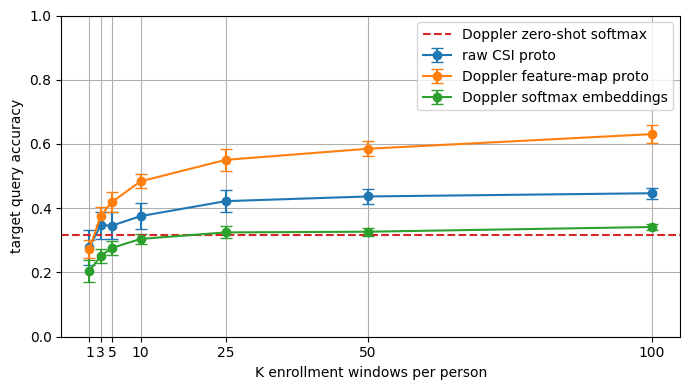

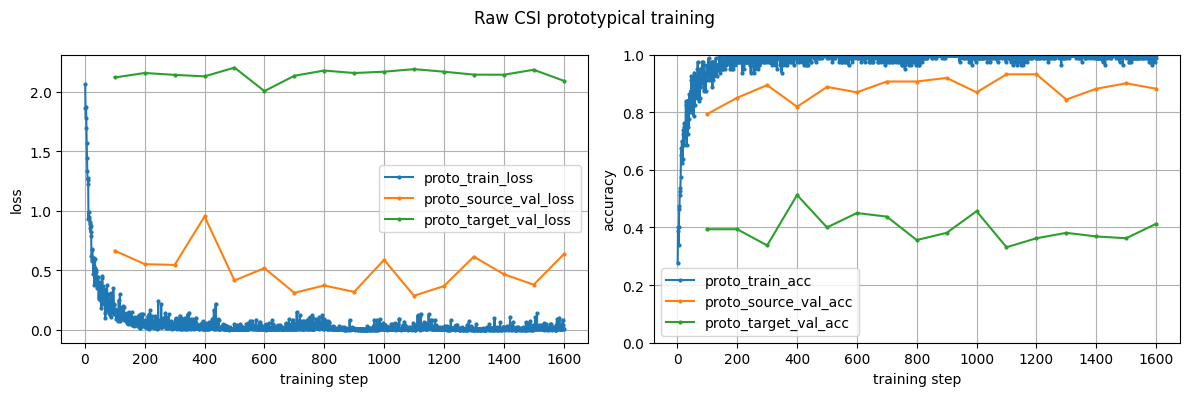

Run directory: C:\Users\gianm\Development\wifi-doppler-har\experiments\few_shot_raw_csi_proto_evaluation\raw_csi_proto_vs_doppler_featuremap_proto_20260529_173630
Results: C:\Users\gianm\Development\wifi-doppler-har\experiments\few_shot_raw_csi_proto_evaluation\raw_csi_proto_vs_doppler_featuremap_proto_20260529_173630\raw_csi_proto_vs_doppler_baselines_results.json
Raw CSI proto model: C:\Users\gianm\Development\wifi-doppler-har\experiments\few_shot_raw_csi_proto_evaluation\raw_csi_proto_vs_doppler_featuremap_proto_20260529_173630\raw_csi_proto_model.pt
Comparison plot: C:\Users\gianm\Development\wifi-doppler-har\experiments\few_shot_raw_csi_proto_evaluation\raw_csi_proto_vs_doppler_featuremap_proto_20260529_173630\raw_csi_proto_vs_doppler_baselines_accuracy.png
Training curves: C:\Users\gianm\Development\wifi-doppler-har\experiments\few_shot_raw_csi_proto_evaluation\raw_csi_proto_vs_doppler_featuremap_proto_20260529_173630\raw_csi_proto_training_curves.png


In [8]:
def result_series(results, k_values):
    means = [results[k]["mean"] for k in k_values]
    stds = [results[k]["std"] for k in k_values]
    return means, stds


raw_means, raw_stds = result_series(raw_proto_fewshot_results, K_VALUES)
doppler_proto_means, doppler_proto_stds = result_series(doppler_featuremap_proto_fewshot_results, K_VALUES)
doppler_softmax_means, doppler_softmax_stds = result_series(doppler_softmax_fewshot_results, K_VALUES)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(K_VALUES, raw_means, yerr=raw_stds, marker="o", capsize=4, label="raw CSI proto")
ax.errorbar(K_VALUES, doppler_proto_means, yerr=doppler_proto_stds, marker="o", capsize=4, label="Doppler feature-map proto")
ax.errorbar(K_VALUES, doppler_softmax_means, yerr=doppler_softmax_stds, marker="o", capsize=4, label="Doppler softmax embeddings")
ax.axhline(zero_shot_softmax_acc, color="tab:red", linestyle="--", label="Doppler zero-shot softmax")
ax.set_xlabel("K enrollment windows per person")
ax.set_ylabel("target query accuracy")
ax.set_ylim(0, 1)
ax.set_xticks(K_VALUES)
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()

history_fig, _ = plot_step_curves(proto_history, loss_keys=["proto_train_loss", "proto_source_val_loss", "proto_target_val_loss"], acc_keys=["proto_train_acc", "proto_source_val_acc", "proto_target_val_acc"], title="Raw CSI prototypical training")
plt.show()

comparison_plot_path = save_figure(fig, run_dir, "raw_csi_proto_vs_doppler_baselines_accuracy.png")
history_plot_path = save_figure(history_fig, run_dir, "raw_csi_proto_training_curves.png")

results = {"zero_shot_softmax_acc": zero_shot_softmax_acc, "raw_proto_fewshot_results": raw_proto_fewshot_results, "doppler_featuremap_proto_fewshot_results": doppler_featuremap_proto_fewshot_results, "doppler_softmax_fewshot_results": doppler_softmax_fewshot_results, "history": proto_history, "config": proto_config, "artifacts": {"comparison_plot": comparison_plot_path, "history_plot": history_plot_path}}

results_path = save_json(run_dir / "raw_csi_proto_vs_doppler_baselines_results.json", results)
model_path = save_checkpoint(proto_model, run_dir, labels=PERSONS, config=proto_config, metrics={"final_proto_train_loss": proto_history["proto_train_loss"][-1], "final_proto_train_acc": proto_history["proto_train_acc"][-1], "final_proto_source_val_loss": proto_history["proto_source_val_loss"][-1], "final_proto_source_val_acc": proto_history["proto_source_val_acc"][-1], "final_proto_target_val_loss": proto_history["proto_target_val_loss"][-1], "final_proto_target_val_acc": proto_history["proto_target_val_acc"][-1], "best_raw_proto_kshot_acc": max(result["mean"] for result in raw_proto_fewshot_results.values()), "best_doppler_featuremap_proto_kshot_acc": max(result["mean"] for result in doppler_featuremap_proto_fewshot_results.values()), "best_doppler_softmax_kshot_acc": max(result["mean"] for result in doppler_softmax_fewshot_results.values()), "zero_shot_softmax_acc": zero_shot_softmax_acc}, history=proto_history, name="raw_csi_proto_model.pt")

print("Run directory:", run_dir)
print("Results:", results_path)
print("Raw CSI proto model:", model_path)
print("Comparison plot:", comparison_plot_path)
print("Training curves:", history_plot_path)
